Things I have to add for numerical data
- ~~'BOX PLOT'~~
- ~~'DENSITY_PLOT'~~
- 'CONNECTED_SCATTER PLOT'
- '3D_SCATTEROR_SURFACE'
- 'PCA'
- 'RIDGE_LINE'
- 'DENDROGRAM'
- 'SCATTER_WITH_MARGINAL_POINT'
- 'BOX_PLOT'
- 'SCATTER_PLOT'
- 'STACKED_AREA_PLOT'
- ~~'VIOLIN_PLOT'~~
- 'AREA(SM)'
- 'STREAM_GRAPH'
- 'LINE_PLOT'
- 'BUBBLE_PLOT'
- '2D_DENSITY_PLOT'
- 'HISTOGRAM'
- 'AREA_PLOT'
- 'CORRELOGRAM'
- 'HEATMAP'

In [199]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [200]:
class Violinplot:
    def __init__(self, df, x=None, y=None, hue=None, order=None, hue_order=None, bw='scott', cut=2, 
                 scale='area', scale_hue=True, gridsize=100, width=0.8, inner='box', split=False, 
                 dodge=True, orient=None, linewidth=None, color=None, palette=None, saturation=0.75, ax=None,
                 title=None, **kwargs):
        """
        This is used to create violinplot figures using seaborn.

        Parameters:
        -----------
        df (pandas.DataFrame or array-like): 
            The data to plot. DataFrame preferred.
        x, y (str, array-like, optional): 
            Variables to use for plotting. Should be in `data` if it is a DataFrame.
        hue (str or array-like, optional): 
            Grouping variable that will produce different violins with different colors.
        order, hue_order (list of strings, optional): 
            Order to plot the categorical levels in. 
        bw ({‘scott’, ‘silverman’, float}, optional): 
            Method to use for calculating bandwidth.
        cut (float, optional): 
            Distance in units of bandwidth size to extend the density past the extreme datapoints.
        scale ({“area”, “count”, “width”}, optional): 
            The method used to scale the width of each violin.
        scale_hue (bool, optional): 
            When using hue nesting, the coloring of the violins are scaled.
        gridsize (int, optional): 
            Number of points in the discrete grid for the KDE computation.
        width (float, optional): 
            Width of a full element when not using hue nesting, or width of all the elements for one 
            level of the major grouping variable.
        inner ({“box”, “quartile”, “point”, “stick”, None}, optional): 
            The representation of the datapoints in the violin.
        split (bool, optional): 
            When using hue nesting with a binary variable split violins.
        dodge (bool, optional): 
            When hue nesting is used, whether elements should be shifted along the categorical axis.
        orient (str, optional): 
            Orientation of the plot. 'v' or 'h'.
        linewidth (float, optional): 
            Line width of the violin outlines.
        color (Matplotlib color, optional): 
            Color for all of the elements.
        palette (seaborn color palatte or dict, optional): 
            Colors to use for the different levels of the hue variable. 
        saturation (float, optional): 
            Proportion of the original saturation to draw colors.
        ax (matplotlib.axes, optional): 
            Pre-existing axes for the plot. Otherwise, a new one is created.
        title (str, optional): 
            Title for the plot.
        **kwargs: 
            Additional keyword arguments are passed to the underlying seaborn boxplot function. 
            Other keyword arguments are passed through to matplotlib.axes.Axes.boxplot().

        Return:
        -------
        None
        """
        self.__df = df
        self.__x = x
        self.__y = y
        self.__hue = hue
        self.__order = order
        self.__hue_order = hue_order
        self.__bw = bw
        self.__cut = cut
        self.__scale = scale
        self.__scale_hue = scale_hue
        self.__gridsize = gridsize
        self.__width = width
        self.__inner = inner
        self.__split = split
        self.__dodge = dodge
        self.__orient = orient
        self.__linewidth = linewidth
        self.__color = color
        self.__palette = palette
        self.__saturation = saturation
        self.__ax = ax
        self.__title = title
        self.__kwargs = kwargs

        self.__plot()

    def __plot(self):
        """
        This is a private method used to create the violinplot.

        """
        plots = sns.violinplot(x=self.__x, y=self.__y, hue=self.__hue, data=self.__df, 
                        order=self.__order, hue_order=self.__hue_order, bw=self.__bw, 
                        cut=self.__cut, scale=self.__scale, scale_hue=self.__scale_hue, 
                        gridsize=self.__gridsize, width=self.__width, inner=self.__inner, 
                        split=self.__split, dodge=self.__dodge, orient=self.__orient, 
                        linewidth=self.__linewidth, color=self.__color, palette=self.__palette, 
                        saturation=self.__saturation, ax=self.__ax, **self.__kwargs)

        if self.__title:
            plt.title(self.__title)

    def save_plot(self, file_name, folder=None, size=(10, 6)):
        """
        This method saves the created plot in the specified directory.

        Args:
            file_name (str): Name of the file
            folder (str, optional): Name of the directory. If not available, it creates one.
            size (tuple, optional): Size of the figure in inches (width, height). Default is (10, 6).

        """
        if folder:
            if not os.path.exists(folder):
                os.makedirs(folder)
            file_name = os.path.join(folder, file_name)
        
        fig = plt.figure(figsize=size)
        self.__plot()
        plt.savefig(file_name)
        plt.close(fig)  # prevent figure to pop up in the notebook
        plt.ion()  # turns the display of the plot back on
        

In [201]:

df = sns.load_dataset('titanic')

In [202]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

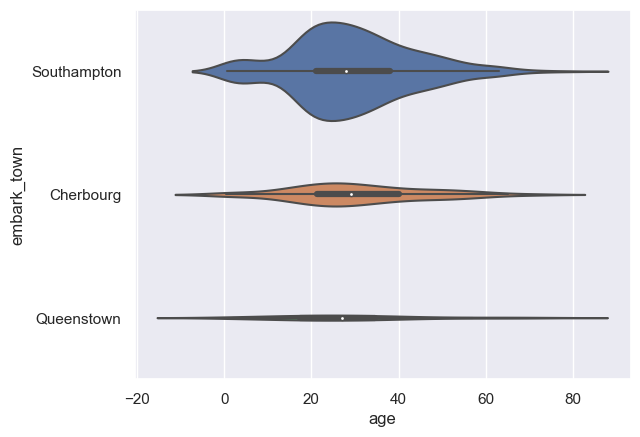

In [203]:
vp = Violinplot(df=df, x="age", y="embark_town", scale="count")

In [204]:
vp.save_plot('violin_plot.png', size=(10, 10))